<a href="https://colab.research.google.com/github/Uttaran1997/svd-image-compression/blob/main/notebooks/01%20image%20as%20matrix.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
print("hello from Colab")

hello from Colab


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data

A = data.camera()

*   data.camera() gives us a built-in grayscale photograph.
*   A is now the matrix representing that image.


In [3]:
print("Shape:", A.shape)
print("Data type:", A.dtype)
print("Smallest entry:", A.min())
print("Largest entry:", A.max())
print("Top-left 3 x 3 block:\n", A[:3, :3])

Shape: (512, 512)
Data type: uint8
Smallest entry: 0
Largest entry: 255
Top-left 3 x 3 block:
 [[200 200 200]
 [200 199 199]
 [199 199 199]]


The A[:3, :3] part means: “show the first 3 rows and first 3 columns.”

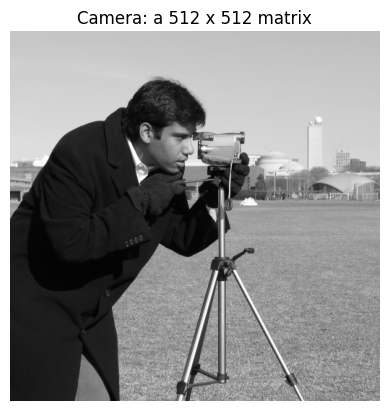

In [4]:
plt.imshow(A, cmap="gray", vmin=0, vmax=255)
plt.title("Camera: a 512 x 512 matrix")
plt.axis("off")
plt.show()

A has shape \(512 \times 512\), so it has 512 rows and 512 columns. It is stored as uint8, meaning each entry is a whole number from 0 to 255. Each entry represents the brightness of one pixel: 0 is black, 255 is white, and values between them are shades of gray.

Color image shape: (512, 512, 3)


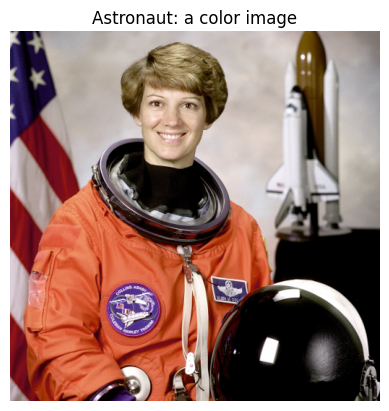

In [5]:
C = data.astronaut()

print("Color image shape:", C.shape)

plt.imshow(C)
plt.title("Astronaut: a color image")
plt.axis("off")
plt.show()

its shape is (512, 512, 3).
The final 3 means the image has three color channels: red, green, and blue.

In [6]:
R = C[:, :, 0]   # red channel
G = C[:, :, 1]   # green channel
B = C[:, :, 2]   # blue channel

print("Red channel shape:", R.shape)
print("Green channel shape:", G.shape)
print("Blue channel shape:", B.shape)

Red channel shape: (512, 512)
Green channel shape: (512, 512)
Blue channel shape: (512, 512)


The color image has shape \(512 \times 512 \times 3\). The first two dimensions give the pixel location, and the third dimension stores red, green, and blue brightness values. We can treat a color image as three separate \(512 \times 512\) matrices.

In [7]:
x = np.array([200], dtype=np.uint8)
y = np.array([100], dtype=np.uint8)

print("uint8 200 + 100 =", x + y)
print("float 200 + 100 =", x.astype(float) + y.astype(float))

uint8 200 + 100 = [44]
float 200 + 100 = [300.]


Adding 200 and 100 as uint8 gives 44 because the value wraps around after 255. Before doing linear algebra with an image, convert its entries to float using .astype(float).

In [9]:
cross = np.array([
    [0, 1, 1, 0],
    [1, 1, 1, 1],
    [1, 1, 1, 1],
    [0, 1, 1, 0]
])

gradient = np.array([
    [i + j for j in range(4)]
    for i in range(4)
])

checker = np.array([
    [(i + j + 1) % 2 for j in range(4)]
    for i in range(4)
])

range(4) means 0,1,2,3

We are defining three small matrices, but we will treat each one as a tiny black-and-white image.

Each entry is a pixel:
- 0 is black
- 1 is white

For example, cross is a 4-by-4 image whose four corners are black and whose other pixels are white. We will soon calculate the rank of each matrix to see how much independent pattern/information the image contains. This connects directly to image compression: lower-rank matrices can often be stored using less information.

In the gradient code: The outer for i in range(4) makes four rows: i = 0, 1, 2, 3.
The inner for j in range(4) makes four entries in each row: j = 0, 1, 2, 3.
Each entry is computed as i + j.

In the checker code: % 2 means “remainder after division by 2,” so it alternates between 0 and 1. That creates a black-and-white checkerboard pattern.

In [10]:
print("Cross rank =", np.linalg.matrix_rank(cross))
print("Gradient rank =", np.linalg.matrix_rank(gradient))
print("Checkerboard rank =", np.linalg.matrix_rank(checker))

Cross rank = 2
Gradient rank = 2
Checkerboard rank = 2


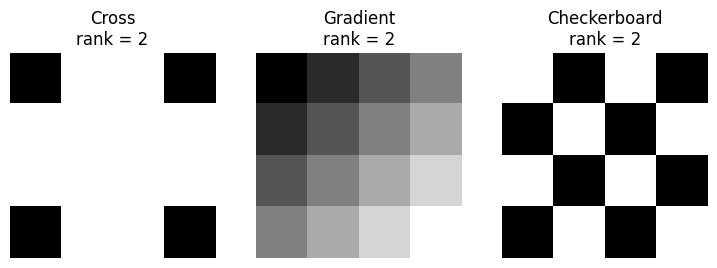

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(9, 3))

images = [
    ("Cross", cross),
    ("Gradient", gradient),
    ("Checkerboard", checker)
]

for ax, (name, M) in zip(axes, images):
    ax.imshow(M, cmap="gray")
    ax.set_title(f"{name}\nrank = {np.linalg.matrix_rank(M)}")
    ax.axis("off")

plt.show()

This makes one row of three plots:
- plt.subplots(1, 3) creates 1 row and 3 plotting spaces.
- zip(axes, images) matches each plotting space with one matrix.
- ax.imshow(...) displays a matrix as an image.
- f"..." lets Python insert the matrix name and calculated rank into the title.

[[1 1 1 1]
 [0 0 0 0]
 [1 1 1 1]
 [0 0 0 0]]
Rank = 1


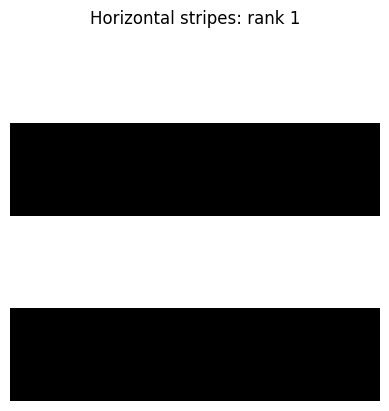

In [14]:
u = np.array([1, 0, 1, 0])
v = np.array([1, 1, 1, 1])

stripes = np.outer(u, v)

print(stripes)
print("Rank =", np.linalg.matrix_rank(stripes))

plt.imshow(stripes, cmap="gray")
plt.title("Horizontal stripes: rank 1")
plt.axis("off")
plt.show()

This image has rank 1 because it is an outer product \(uv^T\). Every row is a multiple of the same row pattern \(v^T\). In a rank-1 image, each row has the same pattern, possibly scaled by a different amount.

In [15]:
from google.colab import files
from PIL import Image

uploaded = files.upload()

Saving images.jpg to images.jpg


Shape: (447, 447)
Data type: uint8


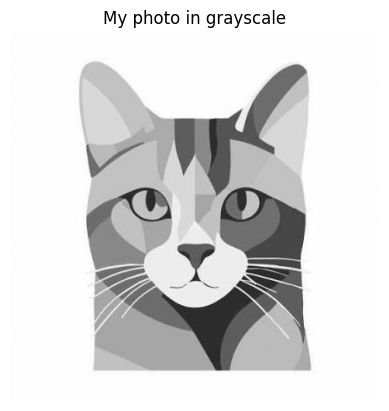

In [16]:
name = list(uploaded)[0]          # gets the uploaded filename
img = Image.open(name).convert("L")  # converts it to grayscale

img.thumbnail((800, 800))         # keeps the image manageable
P = np.array(img)

print("Shape:", P.shape)
print("Data type:", P.dtype)

plt.imshow(P, cmap="gray", vmin=0, vmax=255)
plt.title("My photo in grayscale")
plt.axis("off")
plt.show()

convert("L") changes the photo to grayscale, and thumbnail((800, 800)) reduces a large phone photo so later SVD calculations will not be unnecessarily slow.

- Image.open(name) opens the image file.
- .convert("L") converts it to grayscale.
- img.thumbnail((800, 800)) shrinks it while preserving its proportions.
- P = np.array(img) converts the grayscale image into a NumPy matrix.
- Each entry of P is typically an integer from 0 to 255, representing one pixel’s brightness: 0 is black and 255 is white.
That matrix P is what we will later compress using the SVD.